# 02. 피처 엔지니어링 — DAY 1 전략을 피처 표로 만들기

DAY 1 보고서 5.1에서 정한 피처를 실제로 계산하고, 노션이 경고한 **배치별 측정 시작점 차이**를 확인한다.

| 단계 | 내용 |
|---|---|
| 1 | 학습·평가에 쓸 셀 확정 (정상 119 + 최소 수명 점검용 12) |
| 2 | 배치별 측정 시작점(초기 용량) 차이 확인 → ΔQ가 이 차이를 지우는지 검증 |
| 3 | 피처 세트 A~D 정의와 근거 |
| 4 | 피처 세트별 결측·중복(VIF) 점검 |

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from load_data import load_cells, load_summary, load_qdlin
from features import build_dataset, FEATURE_SETS
import viz
viz.setup()
pd.set_option('display.width', 160)

## 1. 사용할 셀

- **정상(OK)**: 정답이 확실한 셀 → 학습(Batch 1 36) / 테스트(Batch 2 39) / 추가 테스트(Batch 3 44)
- **중도 절단(CENSORED)**: 수명 기준(0.88Ah)에 닿기 전에 기록이 끝난 셀 → 정답은 없지만 *최소 이만큼은 살았다*를 안다
  - Batch 1의 10셀 (DAY 1 보고서 2장)
  - **Batch 3의 2셀 추가**: DAY 1에는 "정답 없음"으로 분류했는데, 다시 보니 2,189·2,237사이클까지 기록됐고 마지막 용량이 0.94·0.97Ah로 아직 수명이 남아 있었다. 정답이 없는 게 아니라 *아주 오래 사는* 셀이다 → 최소 수명 점검에 포함

In [2]:
df = build_dataset()
df.groupby(['batch', 'status']).size().unstack(fill_value=0)

status,CENSORED,OK
batch,,
b1,10,36
b2,0,39
b3,2,44


In [3]:
df[df.status == 'CENSORED'][['batch', 'cell', 'policy', 'min_life']].sort_values('min_life')

,batch,cell,policy,min_life
8,b1,b1_c08,5.4C(40%)-3.6C,878.0
22,b1,b1_c22,6C(30%)-3.6C,890.0
13,b1,b1_c13,5.4C(50%)-3.6C,896.0
12,b1,b1_c12,5.4C(50%)-3.6C,901.0
10,b1,b1_c10,5.4C(50%)-3C,905.0
2,b1,b1_c02,3.6C(80%)-3.6C,1176.0
1,b1,b1_c01,3.6C(80%)-3.6C,1178.0
0,b1,b1_c00,3.6C(80%)-3.6C,1189.0
3,b1,b1_c03,4C(80%)-4C,1225.0
4,b1,b1_c04,4C(80%)-4C,1226.0


## 2. 배치별 측정 시작점 차이 — ΔQ는 이걸 지우는가

노션 주의사항: *"충전 커브 시작 시점이 배치별로 상이 : Qdlin 변수를 단순 비교하면 왜곡 발생"*.
DAY 1 보고서 4.3에서는 "같은 셀끼리 빼니 상쇄될 것"이라고만 쓰고 검증하지 않았다. 여기서 확인한다.

In [4]:
rows = []
for b in ['b1', 'b2', 'b3']:
    q, v, cyc, ids = load_qdlin(b)
    keep = df.set_index('cell').reindex(ids).status.eq('OK').values
    i10, i100 = list(cyc).index(10), list(cyc).index(100)
    q10_total = q[keep, i10, -1]                      # 10번째 사이클 총 방전량 (2.0V까지)
    dq = q[keep, i100] - q[keep, i10]
    rows.append({'배치': b, '셀': keep.sum(),
                 'Q10 총량 평균(Ah)': q10_total.mean(), 'Q10 총량 표준편차': q10_total.std(),
                 'ΔQ 총량 평균(Ah)': dq[:, -1].mean()})
offset = pd.DataFrame(rows).set_index('배치')
offset.round(4)

,셀,Q10 총량 평균(Ah),Q10 총량 표준편차,ΔQ 총량 평균(Ah)
배치,,,,
b1,36,1.0660,0.0089,-0.0073
b2,39,1.0571,0.0092,-0.0134
b3,44,1.0505,0.0073,-0.0046


findfont: Failed to find font weight bold for AppleGothic, now using 400.


PosixPath('/Users/leejinseo/workspace/class20/results/figures/d2_batch_offset.png')

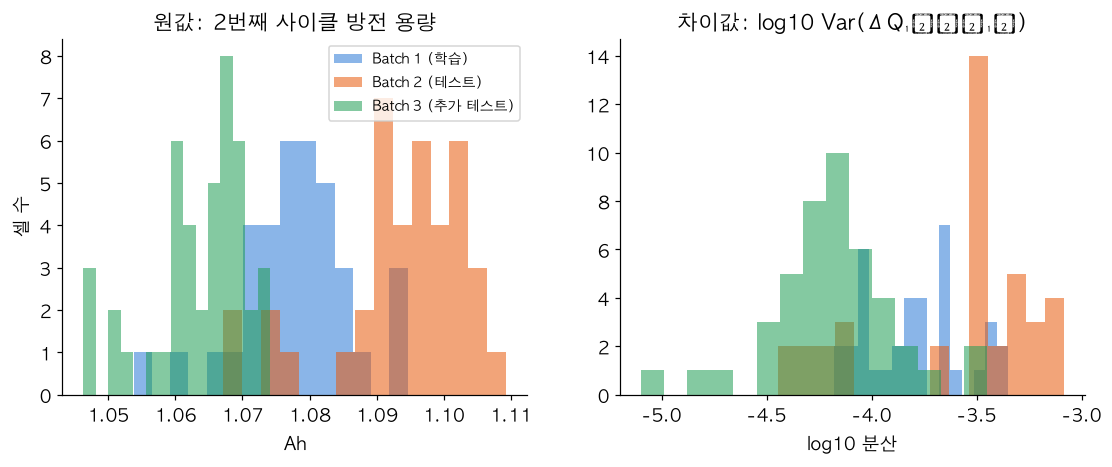

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ok = df[df.status == 'OK']
for b, d in ok.groupby('batch'):
    ax[0].hist(d.qd_2, bins=15, alpha=.55, color=viz.BATCH_COLOR[b], label=viz.BATCH_LABEL[b])
    ax[1].hist(d.dq100_logvar, bins=15, alpha=.55, color=viz.BATCH_COLOR[b], label=viz.BATCH_LABEL[b])
ax[0].set(title='원값: 2번째 사이클 방전 용량', xlabel='Ah', ylabel='셀 수')
ax[1].set(title='차이값: log10 Var(ΔQ₁₀₀₋₁₀)', xlabel='log10 분산')
ax[0].legend(fontsize=9)
viz.save(fig, 'd2_batch_offset')

In [6]:
# 배치 차이가 피처에 얼마나 남는지: 배치 평균 차이를 배치 내 표준편차로 나눈 값 (클수록 배치 차이가 큼)
def batch_shift(col):
    m = ok.groupby('batch')[col].mean(); s = ok.groupby('batch')[col].std().mean()
    return (m.max() - m.min()) / s
pd.Series({c: batch_shift(c) for c in ['qd_2', 'dq100_logvar', 'chargetime_5', 'ir_min', 'tavg_mean']},
          name='배치 간 평균 차이 / 배치 내 표준편차').round(2)

qd_2            3.51
dq100_logvar    1.95
chargetime_5    1.45
ir_min          1.64
tavg_mean       1.27
Name: 배치 간 평균 차이 / 배치 내 표준편차, dtype: float64

**확인 결과**

- 시작 용량이 배치마다 다르다 (위 표·그림 왼쪽). 같은 배터리 모델인데 생산 로트나 실험 시기에 따라 출발점이 다른 것이다.
- ΔQ는 **같은 셀의 100번째 − 10번째**라서 셀마다 붙어 있는 일정한 출발점 차이는 빼기에서 정확히 사라진다. 실제로 ΔQ의 배치 분포 차이는 원값과 달리 *수명 차이 방향*(B2 기존 방식이 가장 크고 수명이 가장 짧음)과 일치한다 (DAY 1 그림 6).
- 다만 원값을 그대로 쓰는 현장 피처(초기 용량 `qd_2` 등)에는 배치 차이가 그대로 남는다 → 피처 세트 C·D에서 배치가 바뀌면 흔들릴 위험. 이건 모델 비교에서 확인한다.
- 남는 한계: ΔQ 자체에도 *배치 간 수명 관계 차이*(DAY 1 4.6, Batch 2 기존 방식 −24%)는 남아 있다. 출발점 차이는 지웠지만, 같은 ΔQ에서 수명이 다른 문제는 피처로 지울 수 없다.

## 3. 피처 세트 A~D (DAY 1 보고서 5.1)

| 세트 | 피처 | 왜 이렇게 구성했나 | 같이 쓸 모델 |
|---|---|---|---|
| **A** | log10 Var(ΔQ) | 세 배치 모두 상관 강하고 방향 동일(−0.84/−0.92/−0.76). 원논문 'variance' 모델과 같은 구성 → 논문과 공정 비교 가능 | 선형 회귀(주력), 트리(비선형 확인) |
| **B** | A + 평균 C-rate + 최대 C-rate | 같은 충전 시간이면 전류를 몰수록 단수명(−0.68/−0.66). 운영사가 바꿀 수 있는 변수라 넣었을 때 효과를 보고 싶음 | ElasticNet, 트리 |
| **C** | ΔQ 통계 5개 + C-rate 2개 + 현장 5개 | 모델이 스스로 고르게 함. ΔQ 통계끼리 r ≥ 0.98 중복 → 규제 필요 | ElasticNet, 트리 |
| **D** | 현장(BMS) 피처 8개, ΔQ 없음 | 실제 ESS는 진단 방전 없이는 ΔQ를 못 잼. 평소 기록만으로 어디까지 되는지 | ElasticNet |

- 선형 회귀는 **A에만** 쓴다. 피처를 늘리면 중복 때문에 계수가 불안정해지므로 그때는 ElasticNet (DAY 1 5.2).
- 결측: Batch 2의 6셀은 내부저항 기록이 없다 → 학습 데이터 중앙값으로 채운다 (Pipeline 안에서 학습 데이터로만 계산해서 누수 없음). 셀을 버리면 테스트 셀 수가 달라져 다른 모델과 비교가 어려워짐.

In [7]:
pd.DataFrame([{'세트': k, '피처 수': len(v), '피처': ', '.join(v),
               '결측 셀(전체)': int(df[v].isna().any(axis=1).sum())} for k, v in FEATURE_SETS.items()])

,세트,피처 수,피처,결측 셀(전체)
0,A,1,dq100_logvar,0
1,B,3,"dq100_logvar, C_avg, C_max",0
2,C,12,"dq100_logvar, dq100_logmin, dq100_logmean, dq1...",6
3,D,8,"qd_2, qd_100_minus_2, fade_slope_2_100, fade_s...",6


In [8]:
# 중복 정도(VIF): Batch 1 정상 셀 기준. 10 이상이면 같은 정보가 많이 겹친다는 뜻
from statsmodels.stats.outliers_influence import variance_inflation_factor
b1 = ok[ok.batch == 'b1']
def vif(cols):
    X = b1[cols].fillna(b1[cols].median())
    X = (X - X.mean()) / X.std()
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(len(cols))], index=cols)
for k in ['B', 'C', 'D']:
    print(f'[{k}]', vif(FEATURE_SETS[k]).round(1).to_dict())

[B] {'dq100_logvar': 3.8, 'C_avg': 3.9, 'C_max': 2.6}
[C] {'dq100_logvar': 466.3, 'dq100_logmin': 1103.4, 'dq100_logmean': 563.9, 'dq100_skew': 17.7, 'dq100_kurt': 4.0, 'C_avg': 288.4, 'C_max': 4.7, 'qd_2': 3.5, 'fade_slope_2_100': 9.0, 'chargetime_5': 275.9, 'ir_min': 3.1, 'tavg_mean': 1.7}
[D] {'qd_2': 1.6, 'qd_100_minus_2': 102.2, 'fade_slope_2_100': 100.1, 'fade_slope_91_100': 5.4, 'ir_min': 2.5, 'ir_100_minus_2': 1.5, 'tavg_mean': 1.2, 'chargetime_5': 1.8}


**정리**

- B는 VIF가 낮아 선형 계열에서도 문제없다.
- C는 ΔQ 통계끼리 VIF가 매우 크다 → 일반 선형 회귀를 쓰면 계수가 흔들림 → ElasticNet으로 규제 (DAY 1 계획 그대로).
- 피처 표는 `features.build_dataset()` 한 함수로 만들어지고, `src/train.py`가 이 함수를 그대로 쓴다.